# Necrotic Area Subtraction from ROI

Remove poorly-perfused/necrotic regions from a segmentation mask using the PE parametric map.

- **PE (Peak Enhancement)**: Remove pixels with PE *below* threshold

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# ===== FILE PATHS =====
PE_PATH = "/Users/samantha/Desktop/ultrasound lab stuff/china data/p11/new_v2/paramap/PE_full_TIC_numerical.npy"
ROI_PATH = "/Users/samantha/Desktop/ultrasound lab stuff/china data/p11/new_v2/paramap/segmentation.npy"
SCAN_PATH = '/Users/samantha/Desktop/ultrasound lab stuff/china data/p11/new_v2/CEUS-24868.nii.gz'
OUTPUT_DIR = "/Users/samantha/Desktop/ultrasound lab stuff/china data/p11/new_v2"

# ===== THRESHOLD =====
# Set value OR percentile (not both)

PE_THRESHOLD = None      # Absolute value, or None to use percentile
PE_PERCENTILE = 15       # Remove bottom 15% of PE values

In [48]:
# Load data
pe = np.load(PE_PATH)
roi = np.load(ROI_PATH)

orig_count = int(np.sum(roi > 0))
print(f"Shapes - PE: {pe.shape}, ROI: {roi.shape}")
print(f"Original ROI: {orig_count:,} pixels")

Shapes - PE: (256, 206, 119), ROI: (256, 206, 119)
Original ROI: 392,310 pixels


## PE Thresholding
Remove pixels with low Peak Enhancement (poor perfusion).

In [49]:
# Calculate threshold
if PE_THRESHOLD is not None:
    pe_thresh = PE_THRESHOLD
else:
    valid_pe = pe[(roi > 0) & np.isfinite(pe) & (pe > 0)]
    pe_thresh = np.percentile(valid_pe, PE_PERCENTILE)

# Apply threshold - remove pixels BELOW threshold
pe_mask = ((roi > 0) & (pe >= pe_thresh) & np.isfinite(pe)).astype(np.float32)

remaining = int(np.sum(pe_mask > 0))
print(f"PE threshold: {pe_thresh:.4f}")
print(f"Removed: {orig_count - remaining:,} pixels ({100*(orig_count-remaining)/orig_count:.1f}%)")
print(f"Remaining: {remaining:,} pixels")

PE threshold: 0.5653
Removed: 63,711 pixels (16.2%)
Remaining: 328,599 pixels


## Visualization

1. TIC Curve

In [ ]:
import nibabel as nib
import os

# Load scan and compute mean TIC within original ROI and thresholded mask
scan_nii = nib.load(SCAN_PATH)
scan = np.asarray(scan_nii.dataobj).astype(np.float32)  # shape: (X, Y, Z, T)

roi_mask = roi > 0
thresh_mask = pe_mask > 0

tic_original = scan[roi_mask].mean(axis=0)
tic_viable = scan[thresh_mask].mean(axis=0)

time = np.arange(len(tic_original))

# Build title from paths
scan_name = os.path.splitext(os.path.splitext(os.path.basename(SCAN_PATH))[0])[0]  # strip .nii.gz
parts = OUTPUT_DIR.rstrip('/').split('/')
patient = next((p for p in parts if p.startswith('p') and p[1:].isdigit()), None)
visit = next((p for p in parts if p.startswith('v') and p[1:].isdigit()), None)
title_label = ' | '.join(filter(None, [patient, visit, scan_name]))

plt.figure(figsize=(10, 4))
plt.plot(time, tic_original, label='Original ROI', color='gray', linestyle='--')
plt.plot(time, tic_viable, label='Necrotic Removed', color='green')
plt.xlabel('Frame')
plt.ylabel('Mean Intensity')
plt.title(f'TIC: Original ROI vs Necrotic Removed\n{title_label}')
plt.legend()
plt.tight_layout()
plt.show()

2. 2D Paramap View

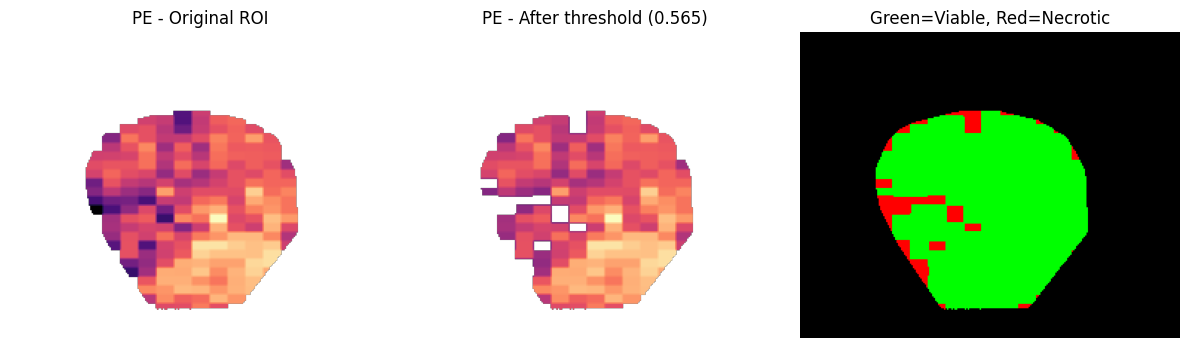

In [18]:
slice_idx = np.argmax([np.sum(roi[:,:,i] > 0) for i in range(roi.shape[2])])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

orig_slice = roi[:,:,slice_idx]
new_slice = pe_mask[:,:,slice_idx]
removed = (orig_slice > 0) & (new_slice == 0)

orig_data = np.where(orig_slice > 0, pe[:,:,slice_idx], np.nan)
vmin, vmax = np.nanmin(orig_data), np.nanmax(orig_data)

axes[0].imshow(np.rot90(orig_data), cmap='magma', vmin=vmin, vmax=vmax)
axes[0].set_title('PE - Original ROI')
axes[0].axis('off')

axes[1].imshow(np.rot90(np.where(new_slice > 0, pe[:,:,slice_idx], np.nan)), cmap='magma', vmin=vmin, vmax=vmax)
axes[1].set_title(f'PE - After threshold ({pe_thresh:.3f})')
axes[1].axis('off')

rgb = np.zeros((*orig_slice.shape, 3))
rgb[new_slice > 0] = [0, 1, 0]
rgb[removed] = [1, 0, 0]
axes[2].imshow(np.rot90(rgb))
axes[2].set_title('Green=Viable, Red=Necrotic')
axes[2].axis('off')

plt.tight_layout()
plt.show()

3. Napari view (3D)

In [12]:
import napari
import nibabel as nib

# Load scan nifti - use middle timeframe for background
scan_nii = nib.load(SCAN_PATH)
scan = np.asarray(scan_nii.dataobj)
mid_frame = scan.shape[-1] // 2
scan_frame = scan[..., mid_frame].astype(np.float32)

# Build the necrotic-removed mask as a nifti (same grid as PE/ROI)
final_mask = (pe_mask > 0).astype(np.uint8)

# Save temp nifti for mask using scan's affine
mask_nii = nib.Nifti1Image(final_mask, scan_nii.affine)
roi_nii = nib.Nifti1Image(roi.astype(np.uint8), scan_nii.affine)

# Use affine transforms so napari aligns them properly
scan_affine = scan_nii.affine
mask_affine = mask_nii.affine

viewer = napari.Viewer()
viewer.add_image(scan_frame.transpose(2,1,0), name='Scan', colormap='gray',
                 scale=np.abs(np.diag(scan_affine)[:3])[::-1])
viewer.add_labels(roi.astype(np.uint8).transpose(2,1,0), name='Original ROI', visible=False, opacity=0.3,
                  scale=np.abs(np.diag(mask_affine)[:3])[::-1])
viewer.add_labels(final_mask.transpose(2,1,0), name='Necrotic Removed', opacity=0.3,
                  scale=np.abs(np.diag(mask_affine)[:3])[::-1])

<Labels layer 'Necrotic Removed' at 0x1133e8190>

# Save

In [50]:
import nibabel as nib

# Load affine and header from original scan
scan_nii = nib.load(SCAN_PATH)
affine = scan_nii.affine
zooms = scan_nii.header.get_zooms()[:3]

final_mask = (pe_mask > 0).astype(np.uint8)

# Save as nifti, explicitly setting zooms from scan header
nii_path = f"{OUTPUT_DIR}/voi_necrotic_removed.nii.gz"
out_img = nib.Nifti1Image(final_mask, affine)
out_img.header.set_zooms(zooms)
nib.save(out_img, nii_path)
print(f"Saved: {nii_path}")

# Save as npy
npy_path = f"{OUTPUT_DIR}/voi_necrotic_removed.npy"
np.save(npy_path, final_mask)
print(f"Saved: {npy_path}")

print(f"Voxels in mask: {int(np.sum(final_mask)):,}")

# Verify zooms saved correctly
saved_zooms = nib.load(nii_path).header.get_zooms()[:3]
print(f"Saved zooms: {saved_zooms}")

Saved: /Users/samantha/Desktop/ultrasound lab stuff/china data/p11/new_v2/voi_necrotic_removed.nii.gz
Saved: /Users/samantha/Desktop/ultrasound lab stuff/china data/p11/new_v2/voi_necrotic_removed.npy
Voxels in mask: 328,599
Saved zooms: (np.float32(0.8379405), np.float32(0.8059454), np.float32(1.6202615))


In [30]:
import pandas as pd
import os
from datetime import datetime

# Get voxel spacing from scan header
scan_nii = nib.load(SCAN_PATH)
pixdim = scan_nii.header.get_zooms()[:3]
voxel_vol_mm3 = float(np.prod(pixdim))

necrotic_count = orig_count - remaining

record = {
    "Scan Path":           SCAN_PATH,
    "PE Threshold":        float(pe_thresh),
    "PE Percentile Used":  PE_PERCENTILE if PE_THRESHOLD is None else None,
    "Voxel Spacing (mm)":  str(tuple(float(x) for x in pixdim)),
    "Voxel Vol (mm3)":     voxel_vol_mm3,
    "Whole Tumor Voxels":  orig_count,
    "Whole Tumor Vol (mm3)": orig_count * voxel_vol_mm3,
    "Whole Tumor Vol (cm3)": orig_count * voxel_vol_mm3 / 1000,
    "Necrotic Voxels":     necrotic_count,
    "Necrotic Vol (mm3)":  necrotic_count * voxel_vol_mm3,
    "Necrotic Vol (cm3)":  necrotic_count * voxel_vol_mm3 / 1000,
    "Remaining Voxels":    remaining,
    "Remaining Vol (mm3)": remaining * voxel_vol_mm3,
    "Remaining Vol (cm3)": remaining * voxel_vol_mm3 / 1000,
    "Timestamp":           datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

csv_path = os.path.join(OUTPUT_DIR, "necrotic_area_stats.csv")
df = pd.DataFrame([record])

if os.path.exists(csv_path):
    existing = pd.read_csv(csv_path)
    mask_col = existing["Scan Path"] == SCAN_PATH
    if mask_col.any():
        existing = pd.concat([existing[~mask_col], df], ignore_index=True)
        existing.to_csv(csv_path, index=False)
        print(f"Updated existing row for {SCAN_PATH}")
    else:
        pd.concat([existing, df], ignore_index=True).to_csv(csv_path, index=False)
        print(f"Appended new row")
else:
    df.to_csv(csv_path, index=False)
    print(f"Created {csv_path}")

print(f"Whole tumor: {orig_count:,} voxels = {orig_count * voxel_vol_mm3:.2f} mm³")
print(f"Necrotic:    {necrotic_count:,} voxels = {necrotic_count * voxel_vol_mm3:.2f} mm³")
print(f"Remaining:   {remaining:,} voxels = {remaining * voxel_vol_mm3:.2f} mm³")

Updated existing row for /Users/samantha/Desktop/ultrasound lab stuff/china data/p34/new_v1/CEUS-26152-1.nii.gz
Whole tumor: 301,141 voxels = 339970.22 mm³
Necrotic:    48,941 voxels = 55251.47 mm³
Remaining:   252,200 voxels = 284718.75 mm³
